# Introduction 

An unsupervised learning system was developed using K-Means, hierarchical clustering, and DBSCAN to group Boston-area cities based on quality-of-life indicators. Cluster labels were automatically generated based on dominant feature characteristics. Results were visualized, enabling users to explore similar cities and filter recommendations based on personal preferences such as safety and education.

##### Business Question: “How can city clustering based on socio-economic and lifestyle factors help guide individuals, businesses, and policymakers in selecting cities that best match specific needs such as education quality, affordability, safety, or entertainment?”

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


# Generating file path
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/boston-city-rankings-2025/BostonCities.csv


In [2]:
# Load Data
df = pd.read_csv("/kaggle/input/boston-city-rankings-2025/BostonCities.csv")
df.sample(3)

,City,OVERALL SCORE,PERCENTILE RANKING,Housing,Safety,Mobility,Health,Entertainment,Diversity,Education,Employment
88,Mansfield,4.90,3.71,3.7,3.0,7.0,2.1,6.5,5.3,6.0,4.7
8,Weston,6.62,9.43,7.8,7.8,4.3,8.5,1.6,7.0,9.0,6.3
87,Rockland,4.90,3.79,5.9,3.0,5.9,8.2,5.6,4.8,2.5,4.1


In [3]:
df.describe()

,OVERALL SCORE,PERCENTILE RANKING,Housing,Safety,Mobility,Health,Entertainment,Diversity,Education,Employment
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,5.256241,5.000000,5.874468,5.151773,4.755319,5.321986,5.117730,5.282270,5.234043,5.051064
std,0.901438,2.917734,1.538200,2.816624,1.547691,2.034211,2.361273,2.779935,2.251026,1.061846
min,2.850000,0.000000,2.800000,0.000000,0.900000,0.700000,0.300000,0.100000,0.800000,2.200000
25%,4.650000,2.500000,4.700000,2.700000,3.600000,3.700000,3.600000,3.000000,3.300000,4.400000
50%,5.190000,5.000000,5.900000,5.100000,4.600000,5.600000,5.300000,5.500000,5.200000,5.000000
75%,5.940000,7.500000,6.900000,7.600000,5.900000,6.800000,6.900000,7.400000,7.300000,5.800000
max,7.310000,10.000000,9.100000,10.000000,9.300000,8.800000,9.500000,9.900000,9.400000,7.500000


In [4]:
df.isnull().sum()

City                  0
OVERALL SCORE         0
PERCENTILE RANKING    0
Housing               0
Safety                0
Mobility              0
Health                0
Entertainment         0
Diversity             0
Education             0
Employment            0
dtype: int64

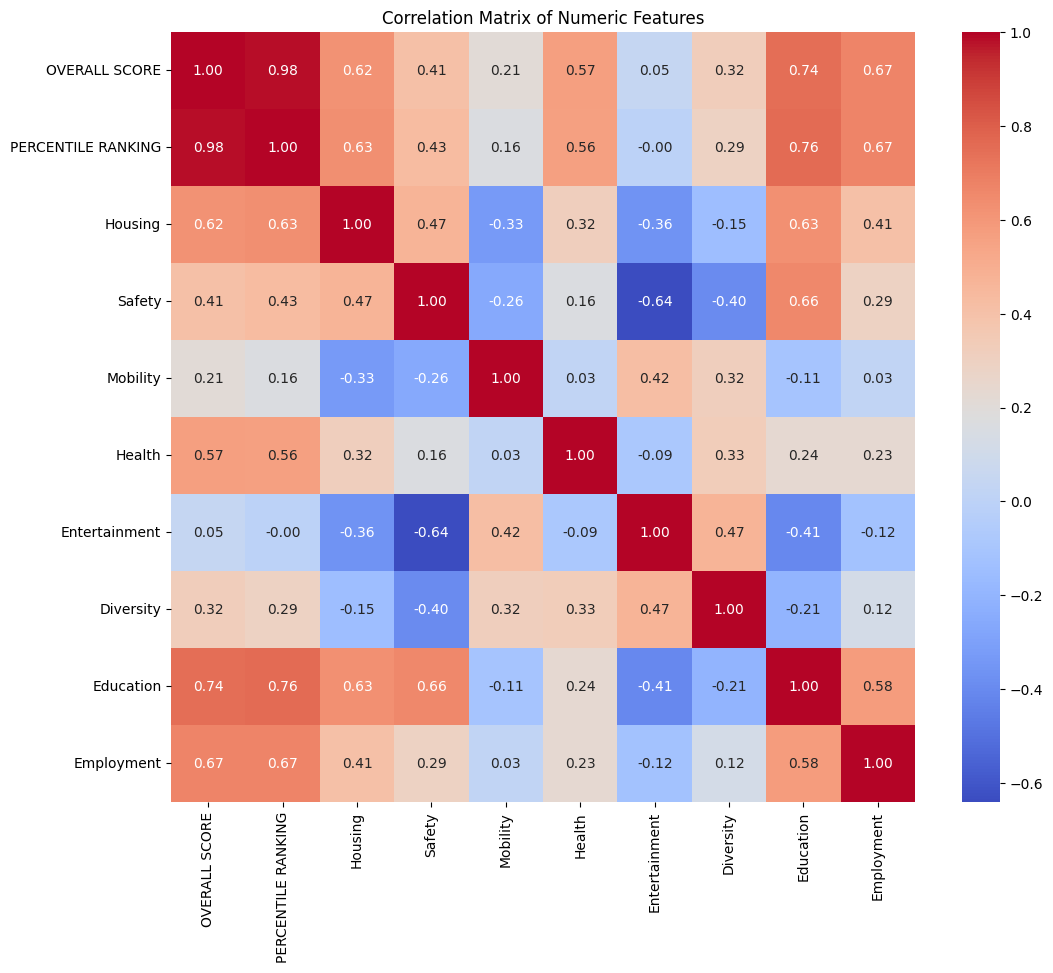

In [5]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

Cities with higher education scores (such as better schools and higher educational attainment) tend to rank much higher overall compared to cities with lower education scores.

# Unsupervised Learning

## Multiple Clustering Models

In [6]:
# Prepare Data
features = ["Housing","Safety","Mobility","Health",
            "Entertainment","Diversity","Education","Employment"]

X = df[features]

scaler = StandardScaler() # reduce noise
X_scaled = scaler.fit_transform(X)

In [7]:
# Clustering using KMeans model
kmeans = KMeans(n_clusters=3, 
                random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)


In [8]:
# Interpret clusters:
df.groupby("KMeans_Cluster")[features].mean()
cluster_profile = df.groupby("KMeans_Cluster")[features].mean()

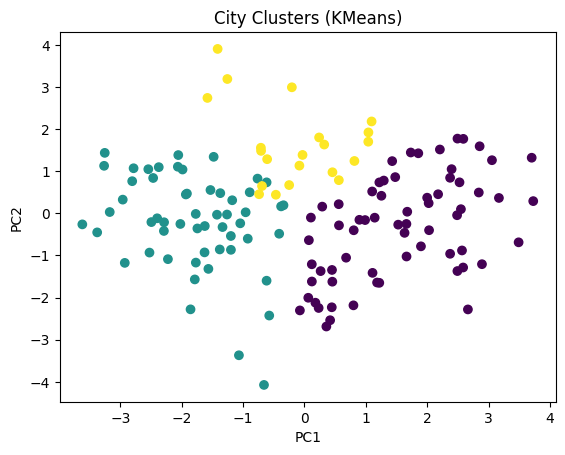

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["KMeans_Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("City Clusters (KMeans)")
plt.show()


In [10]:
# Clustering using Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
df["Hierarchical_Cluster"] = agg.fit_predict(X_scaled)


In [11]:
df.groupby("Hierarchical_Cluster")[features].mean()


,Housing,Safety,Mobility,Health,Entertainment,Diversity,Education,Employment
Hierarchical_Cluster,,,,,,,,
0,7.124561,7.428070,4.149123,5.964912,3.656140,4.747368,7.189474,5.810526
1,5.107407,2.633333,5.135185,5.625926,6.935185,7.374074,3.498148,4.781481
2,4.880000,5.360000,5.223333,3.553333,4.623333,2.533333,4.643333,4.093333


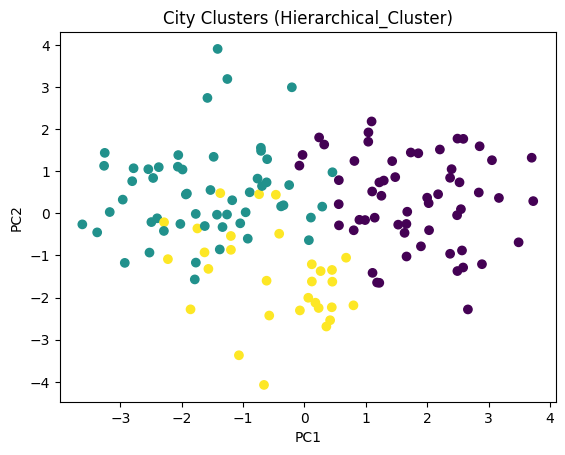

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Hierarchical_Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("City Clusters (Hierarchical_Cluster)")
plt.show()

In [13]:
 # DBSCAN Clustering
dbscan = DBSCAN(eps=1.2, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

In [14]:
# Cluster Labeling

def label_cluster(row):
    if row["Education"] > 5 and row["Diversity"] > 5:
        return "Education & Diversity Hub"
    elif row["Entertainment"] > 5 and row["Mobility"] > 5:
        return "Entertainment & Mobility Hub"
    elif row["Housing"] > 5 and row["Safety"] > 5:
        return "Affordable & Safe Suburban"
    else:
        return "Balanced City"

labels = {}
for cluster in cluster_profile.index:
    labels[cluster] = label_cluster(cluster_profile.loc[cluster])

df["Cluster_Label"] = df["KMeans_Cluster"].map(labels)
df.sample()

,City,OVERALL SCORE,PERCENTILE RANKING,Housing,Safety,Mobility,Health,Entertainment,Diversity,Education,Employment,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster,Cluster_Label
8,Weston,6.62,9.43,7.8,7.8,4.3,8.5,1.6,7.0,9.0,6.3,0,0,-1,Affordable & Safe Suburban


In [15]:

df.groupby("DBSCAN_Cluster")[features].mean()

,Housing,Safety,Mobility,Health,Entertainment,Diversity,Education,Employment
DBSCAN_Cluster,,,,,,,,
-1,5.924427,5.39084,4.722901,5.274046,4.941985,5.067939,5.429008,5.110687
0,5.220000,0.94000,6.040000,6.220000,7.320000,8.940000,2.220000,4.640000
1,5.220000,3.10000,4.320000,5.680000,7.520000,7.240000,3.140000,3.900000


Business Question 1: “Is this city a top-tier city based on its features?”

In [16]:
# Similarity Search

similarity_matrix = cosine_similarity(X_scaled)

def find_similar_cities(city_name, top_n=20):
    idx = df[df["City"] == city_name].index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_indices = [i[0] for i in sim_scores[1:top_n+1]]
    return df.iloc[top_indices][["City"] + features + ["Cluster_Label"]]

print("Cities similar to Cambridge:")
print(find_similar_cities("Cambridge"))

print("\nCities similar to Wellesley:")
print(find_similar_cities("Wellesley"))

Cities similar to Cambridge:
             City  Housing  Safety  Mobility  Health  Entertainment  \
22      Watertown      4.6     2.2       7.7     8.2            8.0   
4      Somerville      7.3     3.6       9.0     6.6            9.0   
2       Brookline      5.1     5.9       7.8     8.2            8.0   
43         Canton      4.8     3.0       5.7     6.1            6.0   
14        Andover      6.0     6.8       7.1     6.2            5.8   
27         Natick      6.8     2.2       5.0     6.6            8.3   
37        Medford      6.9     2.5       6.4     6.4            7.6   
72         Boston      3.6     0.2       7.6     4.3            8.5   
9       Arlington      5.2     7.5       6.5     8.4            6.5   
26  North Andover      6.4     7.2       6.1     5.9            7.1   
66          Salem      5.4     0.4       6.2     6.5            8.8   
71      Stoughton      5.8     1.0       6.0     5.9            7.0   
54     Foxborough      5.3     1.3       6.2    

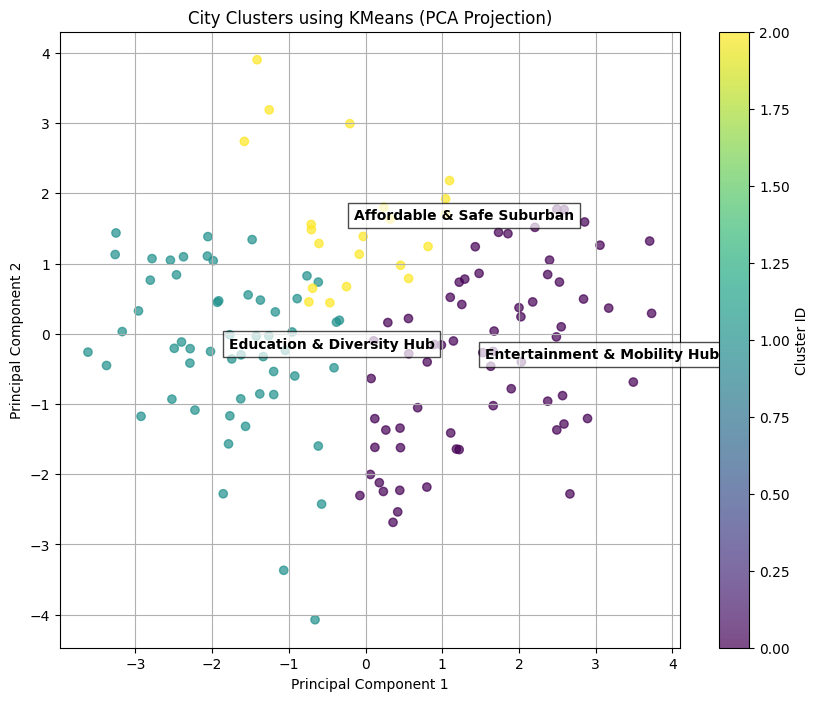

In [17]:
# PCA using KMeans
# The K-Means model successfully identified meaningful city groups based on quality-of-life indicators.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.7
)

# Compute cluster centers in PCA space
cluster_centers = []
cluster_names = df.groupby("KMeans_Cluster")["Cluster_Label"].first()

for cluster in df["KMeans_Cluster"].unique():
    cluster_points = X_pca[df["KMeans_Cluster"] == cluster]
    center_x = cluster_points[:,0].mean()
    center_y = cluster_points[:,1].mean()
    cluster_centers.append((center_x, center_y))

# Add cluster name labels
for i, (x, y) in enumerate(cluster_centers):
    plt.text(
        x, y,
        cluster_names[i],
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(facecolor="white", alpha=0.7)
    )

plt.title("City Clusters using KMeans (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()


This chart is a PCA visualization of K-means clustering results for Boston-area cities based on features such as housing, safety, mobility, health, entertainment, diversity, education, and employment.

1. Cities that are close together have similar characteristics.

2. Cities that are far apart are very different.

The PCA projection of K-Means clustering reveals three distinct groups of cities with shared socio-economic and lifestyle characteristics. Cluster 0 represents entertainment and mobility hubs, Cluster 1 highlights education and diversity-focused cities, and Cluster 2 identifies affordable and safe suburban areas. The visualization demonstrates clear separation between clusters, indicating that the model effectively captured meaningful patterns in the dataset.

Cluster 0 (Purple) – Entertainment & Mobility Hub. Cities in this cluster score high in entertainment, mobility, and urban lifestyle indicators. These are likely more urban, vibrant cities (like Cambridge or Somerville), with better transport and nightlife.

Cluster 1 (Green) – Education & Diversity Hub. Cities in this cluster are characterized by high education, high diversity, strong health, and community indicators. These cities are often academic and multicultural centers.

Cluster 2 (Yellow) – Affordable & Safe Suburban. Cities in this cluster show higher housing affordability, higher safety, and more suburban characteristics. These are more suitable for families and people seeking stability and a lower cost of living.

# Evaluating Clustering Models

In [18]:
# Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["KMeans_Cluster"])
print("Silhouette Score:", score)


Silhouette Score: 0.16980707656006883


In [19]:
# Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_scaled, df["KMeans_Cluster"])
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.5233009782964129


In [20]:
# Calinski-Harabasz Index
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X_scaled, df["KMeans_Cluster"])
print("Calinski-Harabasz Score:", ch_score)

Calinski-Harabasz Score: 39.77397713467149


# Choosing Best Number of Clusters

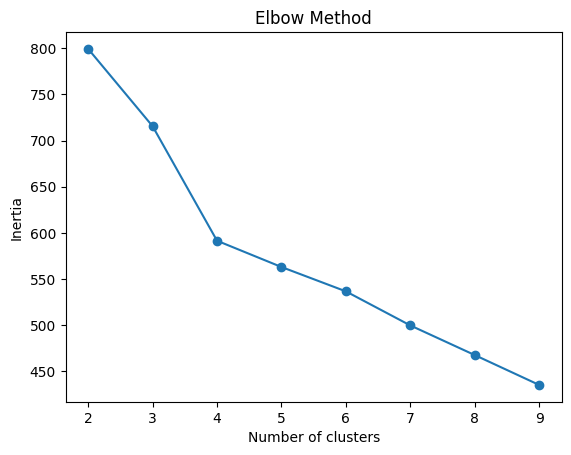

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


The optimal number of clusters is likely 4, as this represents the point where adding more clusters yields smaller marginal gains in explaining the variance. Using 4 clusters would balance model simplicity with clustering accuracy.

##### Business Question 2: “I want high safety and education but moderate housing cost”

In [22]:
# Evaluating Recommendation System (City Suggestion Engine)
recommended = df.sort_values(
    by=["Safety","Education","Housing"],
    ascending=[False, False, True] # true because lower housing is better
).head(10)

print(recommended[["City","Safety","Education","Housing"]])


             City  Safety  Education  Housing
107     Groveland    10.0        5.1      4.1
13        Wayland     9.8        8.7      7.4
19         Wenham     9.8        8.1      8.9
11          Dover     9.7        9.4      6.7
21   Southborough     9.7        7.7      8.2
76        Boxford     9.7        7.6      6.1
25       Carlisle     9.4        8.9      8.8
33       Westford     9.4        7.5      7.0
83         Nahant     9.4        5.2      6.4
6       Lexington     9.3        8.7      7.0


In [23]:
# Create a weighted recommendation score
df["Recommendation_Score"] = (
    0.4 * df["Safety"] +
    0.4 * df["Education"] -
    0.2 * df["Housing"]   # subtract because lower housing cost is better
)

# Sort and get the best city
best_city = df.sort_values(by="Recommendation_Score", ascending=False).head(3)

print("Best city based on your preferences:")
print(best_city[["City", "Safety", "Education", "Housing", "Recommendation_Score"]])


Best city based on your preferences:
                     City  Safety  Education  Housing  Recommendation_Score
11                  Dover     9.7        9.4      6.7                  6.30
59  Manchester by-the-Sea     8.9        9.0      5.2                  6.12
13                Wayland     9.8        8.7      7.4                  5.92


# Recommendation:

Dover is the best match because it has Very high Safety (0.97), the highest education (1.0), moderate housing costs (0.62), and the highest combined score among all cities.

Business Question 3: Types of business investments make strategic sense because the target markets, workforce, and lifestyle priorities differ.

Cambridge-Like Cities

Cities similar to Cambridge, including Somerville, Brookline, Watertown, Boston, Andover, and North Andover, present a distinctive profile for strategic business investment due to their high mobility, diverse population, and strong emphasis on education and cultural amenities. The urban and suburban density of these cities, coupled with a younger, tech-savvy demographic, supports the proliferation of technology startups and innovation hubs, particularly in sectors such as software development, artificial intelligence, financial technology, and educational technology. Furthermore, the presence of universities and professional clusters creates a favorable environment for co-working spaces and incubation centers, providing networking and event-oriented opportunities for freelancers and entrepreneurs. The high diversity and disposable income levels also enable investment in premium retail, lifestyle services, and cultural products, including boutique gyms, specialty restaurants, and art-focused ventures. In addition, mobility-focused businesses such as micro-mobility solutions, ride-sharing services, and smart urban logistics, as well as sustainable and green enterprises, are well-positioned to thrive. Collectively, these factors indicate that investments leveraging human capital, urban density, cultural diversity, and consumer spending power are most likely to succeed in Cambridge-like cities.

Wellesley-Like Cities

In contrast, Wellesley-like cities such as Sudbury, Acton, Weston, Lexington, Newton, and Walpole are characterized by high safety and health standards, moderate to high housing costs, and a pronounced focus on quality of life, including educational excellence and outdoor recreation. These suburban, family-oriented communities are less dependent on public transportation and more reliant on private mobility, which shapes the type of businesses likely to succeed. Investment opportunities in these cities are strongly aligned with family-centric and premium services, such as childcare, educational enrichment programs, and extracurricular activities in sports, arts, and STEM. Healthcare and wellness industries, including clinics, preventive care services, fitness studios, and health-conscious retail, are also well-positioned to cater to affluent, health-conscious residents. Furthermore, high-end residential developments, local specialty retail, leisure and recreation facilities, and professional services including legal, accounting, and real estate advisory are consistent with the priorities of suburban households. The overall strategic insight is that businesses that enhance quality of life, provide convenience, and target affluent families are most suitable for Wellesley-like cities.

Cross-Cluster Opportunities

Certain cities, notably Newton and Walpole, occupy an intermediate position between the Cambridge-like and Wellesley-like clusters, combining moderate diversity with suburban lifestyle characteristics. This hybrid positioning provides a unique opportunity for mixed business models that cater both to family-oriented populations and to younger, mobile professionals. For instance, boutique co-working spaces or innovation centers can coexist with family services such as childcare and educational programs. Similarly, mobility-based services like e-bikes and delivery applications are likely to perform well in Cambridge-like environments, whereas car-oriented services such as premium ride-share and suburban logistics are more appropriate in Wellesley-like suburbs. By strategically aligning investment offerings with the demographic and infrastructural nuances of these cross-cluster cities, businesses can capitalize on diverse consumer needs while leveraging transitional market advantages.